In [1]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
# jax.config.update("jax_debug_nans", True)

device = jax.local_devices()[0]
print(device.device_kind)

stats = device.memory_stats()
free = stats["bytes_limit"] - stats["bytes_in_use"]
print(f"Total VRAM : {stats['bytes_limit'] / 1024**3:.2f} GB")
print(f"In use     : {stats['bytes_in_use'] / 1024**3:.2f} GB")
print(f"Free       : {free / 1024**3:.2f} GB")

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import amigo
import dorito
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

if jax.config.read("jax_enable_x64"):
    print("64bit enabled")
else:
    print("32bit enabled")

import equinox
import lineax

print("jax version:", jax.__version__)
print("zodiax version:", zodiax.__version__)
print("amigo version:", amigo.__version__)
print("dorito version:", dorito.__version__)

print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)

NVIDIA H200
Total VRAM : 104.79 GB
In use     : 0.00 GB
Free       : 104.79 GB
64bit enabled
jax version: 0.8.3
zodiax version: 0.4.1
amigo version: 0.0.10
dorito version: 0.2.0
equinox version: 0.13.7
lineax version 0.1.0


# Loading in data

In [2]:
# Setting data path
from socket import gethostname

print(f"host name: {gethostname()}")

if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/morgana2/snert/max/data/JWST/"
    cache_dir = "/Volumes/morgana2/snert/max/data/amigo_cache"
    amigo_files_path = "/Volumes/morgana2/snert/max/data/amigo_files/v_0.0.10"
    output_path = "/Users/mc/outputs/retrain"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.10"
    output_path = "/home/dgxuser/max/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.10"
    output_path = "/fred/oz440/max/outputs/retrain"

# cleaning directory of empty folders
for d in os.listdir(output_path):
    this_dir = os.path.join(output_path, d)
    fs = os.listdir(this_dir)
    if len(fs) == 0:
        os.rmdir(this_dir)

# dealing with saving figures when running in script
def check_script():
    if "__file__" in globals():
        print("Running as a script")
        return True
    else:
        print("Running in a notebook or interactive shell")
        return False

# Quick toggle flags
all_data_flag = False
one_filt_flag = True
plot_flag = True
save_flag = False
# save_flag = check_script()

job_id = os.environ.get("SLURM_ARRAY_JOB_ID")
if job_id is None:
    from datetime import datetime
    form = "%y-%m-%d_%H-%M-%S_%f"
    now = datetime.now()
    job_id = now.strftime(form)
print(f"Job ID: {job_id}")
save_path = os.path.join(output_path, job_id)
if not os.path.exists(save_path):
    os.makedirs(save_path)

# logging outputs in a text file
if check_script():

    import shutil
    shutil.copy(__file__, save_path + "/script.py")
    
    log_path = os.path.join(save_path, "output.txt")

    class Tee:
        def __init__(self, filename):
            self.file = open(filename, "w")
            self.stdout = sys.stdout

        def write(self, message):
            self.stdout.write(message)
            self.file.write(message)

        def flush(self):
            self.stdout.flush()
            self.file.flush()

    sys.stdout = Tee(log_path)
    sys.stderr = sys.stdout  # capture errors too

    print("Logging to file AND terminal now.")
        
print(f"Save path: {save_path}")
print(f"amigo_files_path: {amigo_files_path}")

host name: max-imagev2-0-6
Job ID: 26-05-13_06-39-45_535020
Running in a notebook or interactive shell
Save path: /home/dgxuser/max/outputs/retrain/26-05-13_06-39-45_535020
amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.10


In [3]:
# Add extra bad pixels
badpix = np.load(f"{cache_dir}/full_badpix.npy")
badpix = np.array(badpix, dtype=int)

def add_badpix(file):
    file["BADPIX"].data = badpix
    file["BADPIX"].data[25, 74] = 1
    return file


# Visualising metadata in a table
def summarise_files(files):
    prog_ids = []
    fnames = []
    targets = []
    filts = []
    diths = []
    ngroups = []
    time = []
    pis = []
    cals = []

    for file in files:
        header = file[0].header

        prog_ids.append(header["PROGRAM"][1:])
        fnames.append(header["FILENAME"][:25])
        targets.append(header["TARGPROP"])
        filts.append(header["FILTER"])
        diths.append(f"{header["PATT_NUM"]}/{header["NUMDTHPT"]}")
        ngroups.append(f"{header["NGROUPS"]}/{header["NINTS"]}")
        time.append(header["DATE-BEG"])
        pis.append(header["PI_NAME"])
        try:
            cals.append(header["IS_PSF"])
        except KeyError:
            cals.append("FLAT")

    df = pd.DataFrame(
        {
            "program": prog_ids,
            # "filename": fnames,
            "target": targets,
            "filter": filts,
            "dither": diths,
            "g/i": ngroups,
            "date": time,
            "PI": pis,
            "CAL": cals,
        }
    )
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df = df.assign(date=pd.to_datetime(df["date"]).dt.strftime("%d-%m-%Y"))

    with pd.option_context(
        "display.expand_frame_repr",
        False,
        "display.max_columns",
        None,
        "display.max_rows",
        None,
        "display.width",
        1000,
    ):
        print(df)

    # df.to_excel("cal_data.xlsx", index=False)

In [4]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files
from dorito.misc import truncate_files


dark_files = []
print()
print("DARKS")
program_path = os.path.join(data_dir, "DARKS/calslope/")
files = get_files(program_path, "nis_calslope", EXP_TYPE="NIS_DARK")
dark_files += files
# for f in dark_files:
#     f["BADPIX"].data = 

# dark_files = dark_files[1:2]  # NOTE DITCHING THE 800 GROUP ONE
# dark_files = dark_files[0:1]  # NOTE DITCHING THE OTHER ONE
dark_files = [add_badpix(file) for file in dark_files]
truncate_files(dark_files, 500)  # TRUNCATING RAMP
summarise_files(dark_files)


DARKS
  program   target filter dither      g/i date             PI   CAL
0    1499  UNKNOWN  F430M    1/1  800/270  NaN  Martel, Andre  FLAT
1    6652  UNKNOWN  F430M    1/1  50/3752  NaN  Martel, Andre  FLAT


# Exposures

In [5]:
from amigo.model_fits import ModelFit
import dLux as dl
from dLux import utils as dlu

class DarkFit(ModelFit):

    def __init__(self, file, fit_one_on_fs=False, **kwargs):
        file[0].header["IS_PSF"] = False

        super().__init__(file, **kwargs)
        self.star = "NIS_DARK"
        self.observation = "DARK"
        self.program = "DARK"
        self.fit_one_on_fs = fit_one_on_fs
        self.fit_reflectivity = False
        self.fit_bias = False
        self.validator = False

    def print_summary(self):
        print(
            f"File {self.key}\n"
            f"Star {self.star}\n"
            f"nints {self.nints}\n"
            f"ngroups {len(self.slopes)+1}\n"
        )

    def initialise_params(self, optics, vis_model=None, one_on_fs_order=1):
        params = {}

        im = np.where(self.badpix, np.nan, self.slopes[0])
        # psf = np.where(np.isnan(im), 0.0, im)

        # dark current
        params["dark_A"] = (
            self.get_key("dark_A"),
            np.array(0.443),
        )

        # One on fs
        if self.fit_one_on_fs:
            params["one_on_fs"] = (
                self.get_key("one_on_fs"),
                np.zeros((self.ngroups, 80, one_on_fs_order + 1)),
            )

        return params

    @property
    def key(self):
        return "_".join(["dark", str(self.ngroups)])

    def get_key(self, param):

        # Unique to each exposure
        if param in [
            "dark_A",
            "one_on_fs",
        ]:
            return self.key

        raise ValueError(f"Parameter {param} has no key")

    # def map_param(self, exposure, param):
    def map_param(self, param):
        """
        The `key` argument will return only the _key_ extension of the parameter path,
        which is required for object initialisation.
        """

        # Map the appropriate parameter to the correct key
        if param in [
            "dark_A",
            "one_on_fs",
        ]:
            return f"{param}.{self.get_key(param)}"

        # Else its global
        return param

    def model_illuminance(self, model):
        """
        There is no illuminance! Haha!
        """
        # Get the pixel scale (arcseconds)
        pixel_scale = model.optics.psf_pixel_scale / model.optics.oversample
        npix = model.optics.psf_npixels * model.optics.oversample

        # illuminance is just zeros
        illuminance = np.zeros((npix, npix))

        # Make the object and return
        return dl.PSF(illuminance, dlu.arcsec2rad(pixel_scale))

    def update_read(self, model):
        read = model.read
        if "dark_A" in model.params.keys():
            dark_current = model.dark_A[self.get_key("dark_A")]
            read = read.set("dark_current", dark_current)
        return read

    def model_read(self, ramp, model):
        model = model.set("read", self.update_read(model))
        return super().model_read(ramp, model)

    def simulate(self, model, return_slopes=False):
        illuminance = self.model_illuminance(model)
        ramp = self.model_ramp(illuminance, model)
        ramp = self.model_read(ramp, model)

        if return_slopes:
            return ramp.set("data", np.diff(ramp.data, axis=0))
        return ramp

In [6]:
# Construct the exposures
dark_exposures = [DarkFit(file, use_cov=False) for file in dark_files]
exposures = dark_exposures

_ = [f.close() for f in dark_files]

# Building model

In [7]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import LinearDetector
from amigo.ramp_models import NonLinearRamp
from amigo.read_models import ReadModel

load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

# Get the model
model = AmigoModel(
    exposures=exposures,
    optics=AMIOptics(static=True),
    detector=LinearDetector(),
    ramp_model=NonLinearRamp(),
    read=ReadModel(),
    # state=load_dict(amigo_files_path + "/calibration.npy"),
)

Populate from state.

In [8]:
state = load_dict(amigo_files_path + "/calibration.npy")
print(state.keys())

for key, value in state.items():
    # if key in ["positions", "fluxes", "aberrations", "nn_weights"]:
    if key in ["positions", "fluxes", "aberrations"]: #, "nn_weights"]:
        continue
    if key in ["transmission", "badpix", "SRF"]:
        continue
    model = model.set(key, value)

# ab_dict = {}
# for key, _ in model.aberrations.items():
#     prog, filt = key.split("_")
#     ab_dict[key] = state["aberrations"][filt]

# model = model.set("aberrations", ab_dict)


# initial normalisations
ff = model.FF
ff -= np.median(ff) - 1.
ff = ff.at[badpix].set(1.)
model = model.set("FF", ff)

non_lin = model.non_linearity.at[:, badpix].set(0)
model = model.set("non_linearity", non_lin)

dict_keys(['FF', 'SRF', 'non_linearity', 'jitter', 'dark_current', 'defocus', 'nn_weights', 'aberrations', 'transmission', 'badpix'])


DARK F430M NIS_DARK 500 270


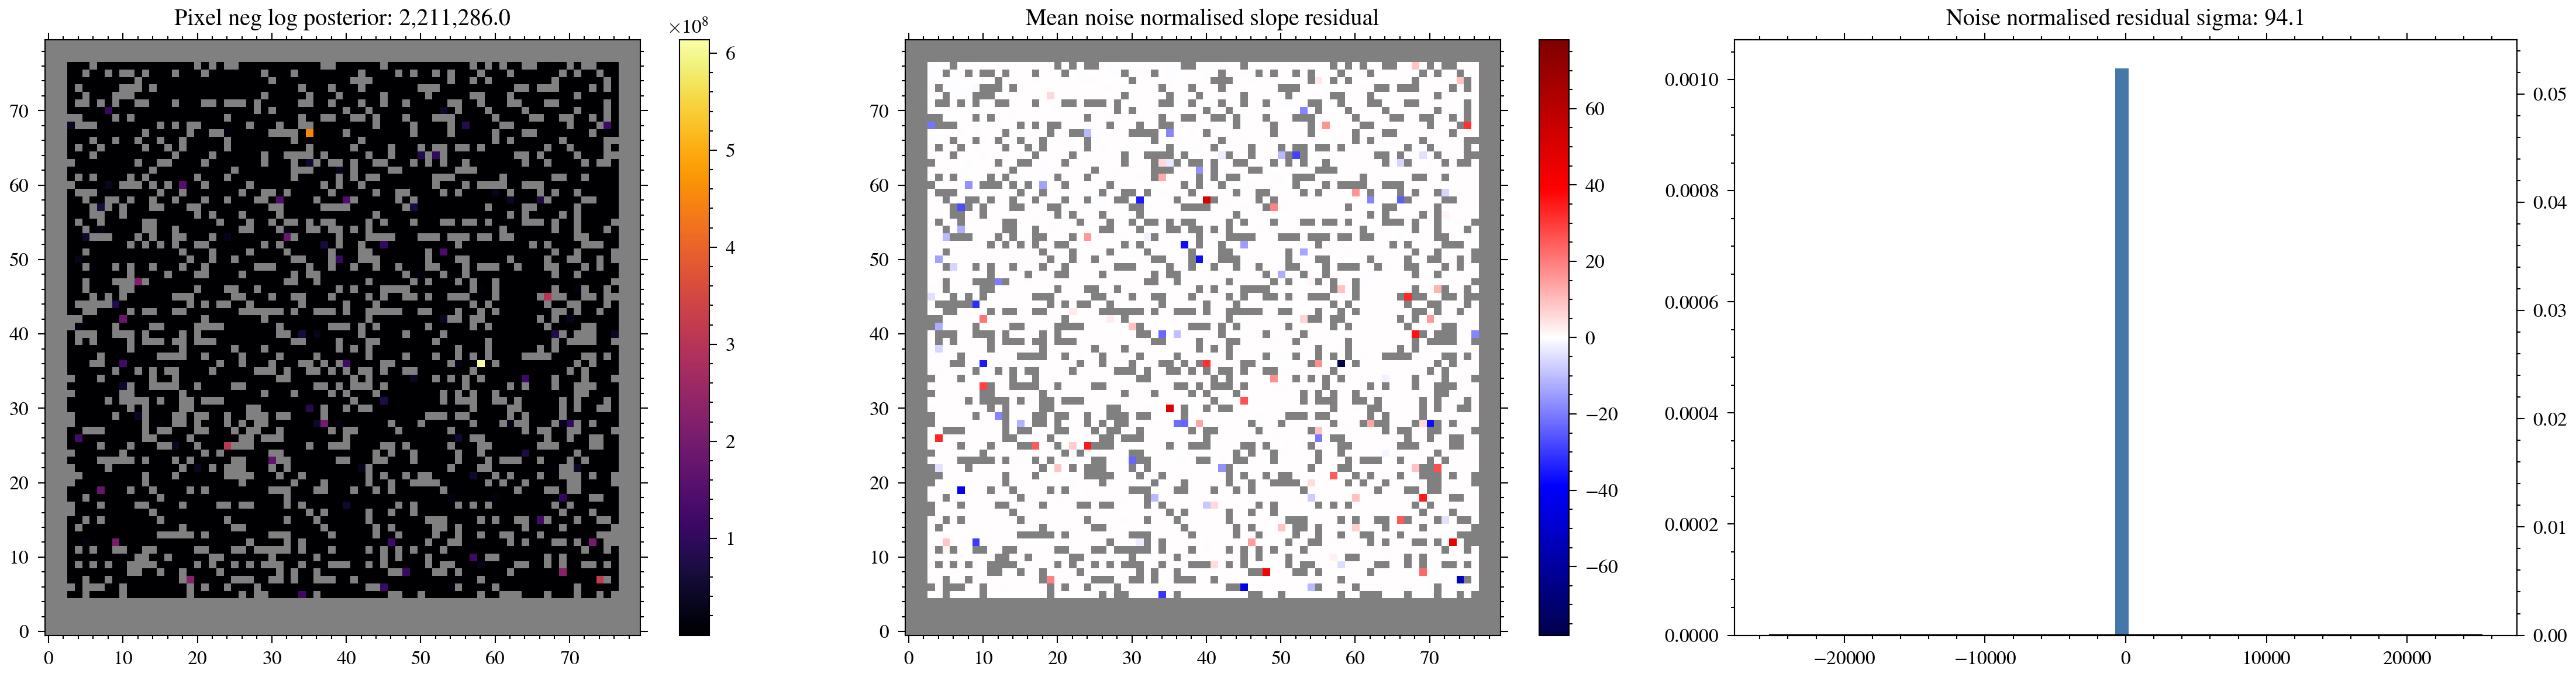

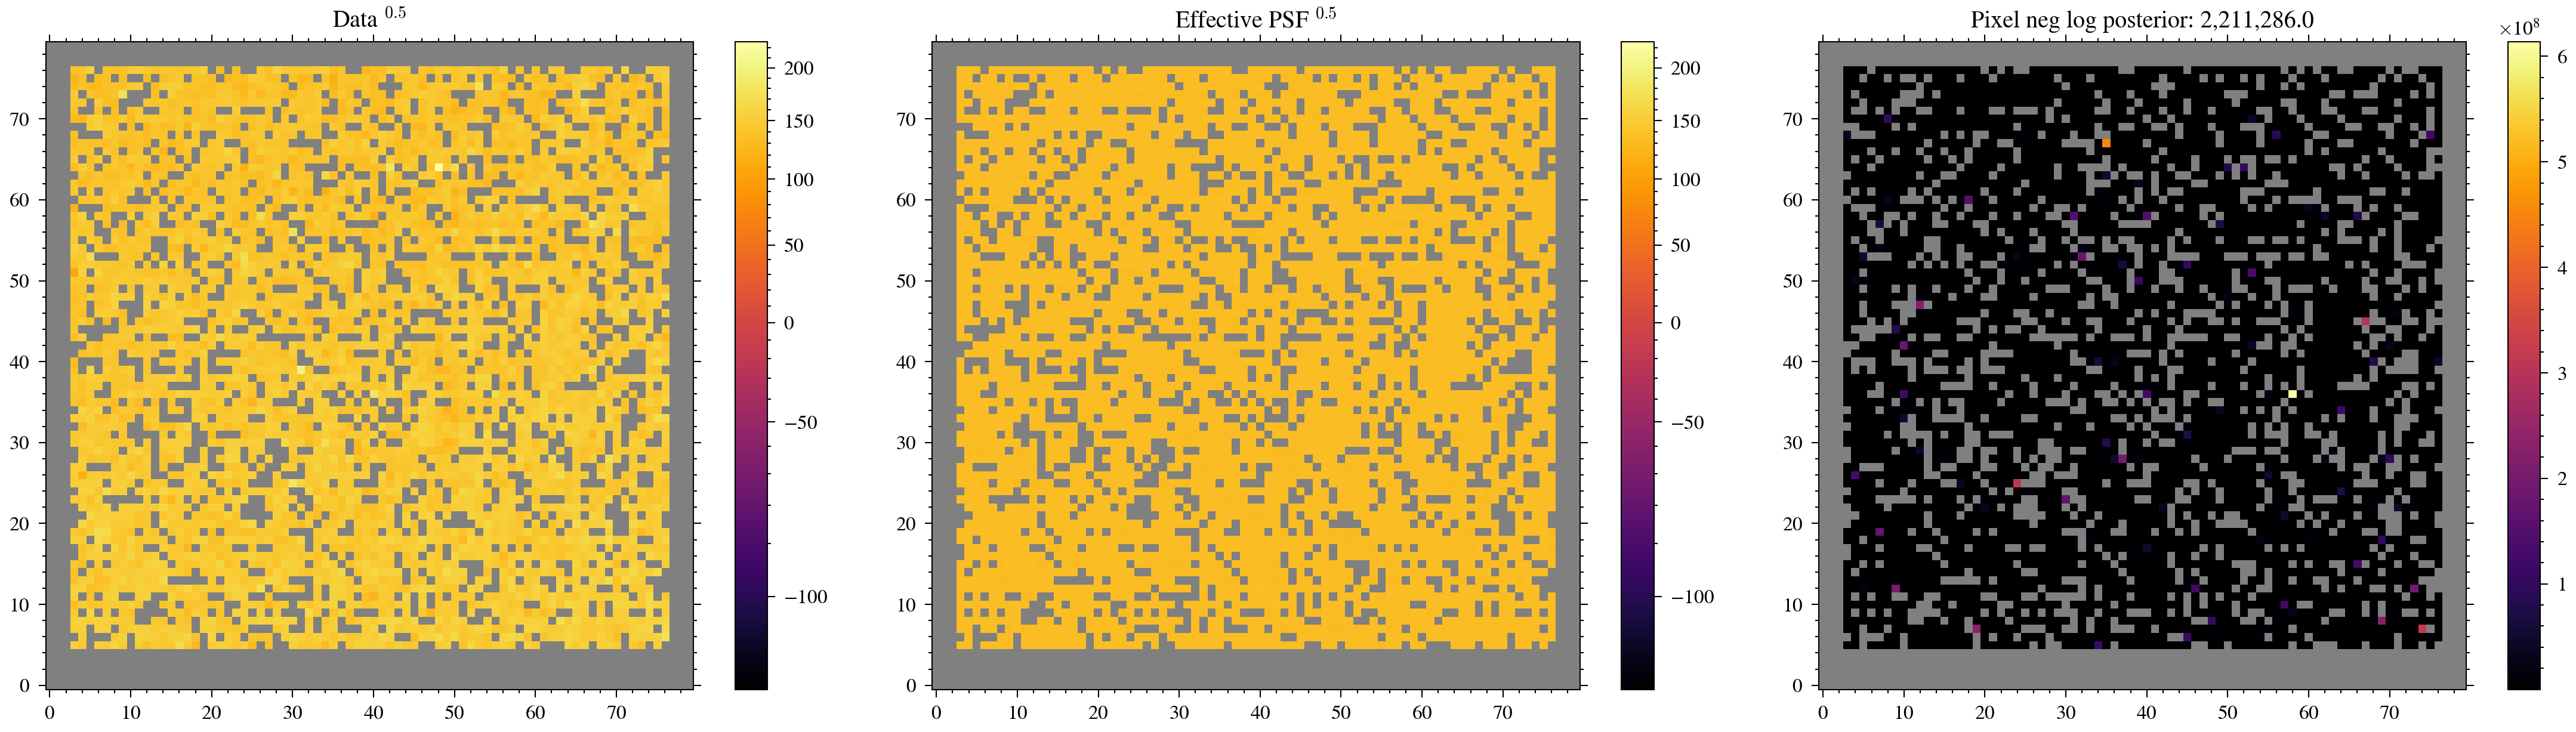

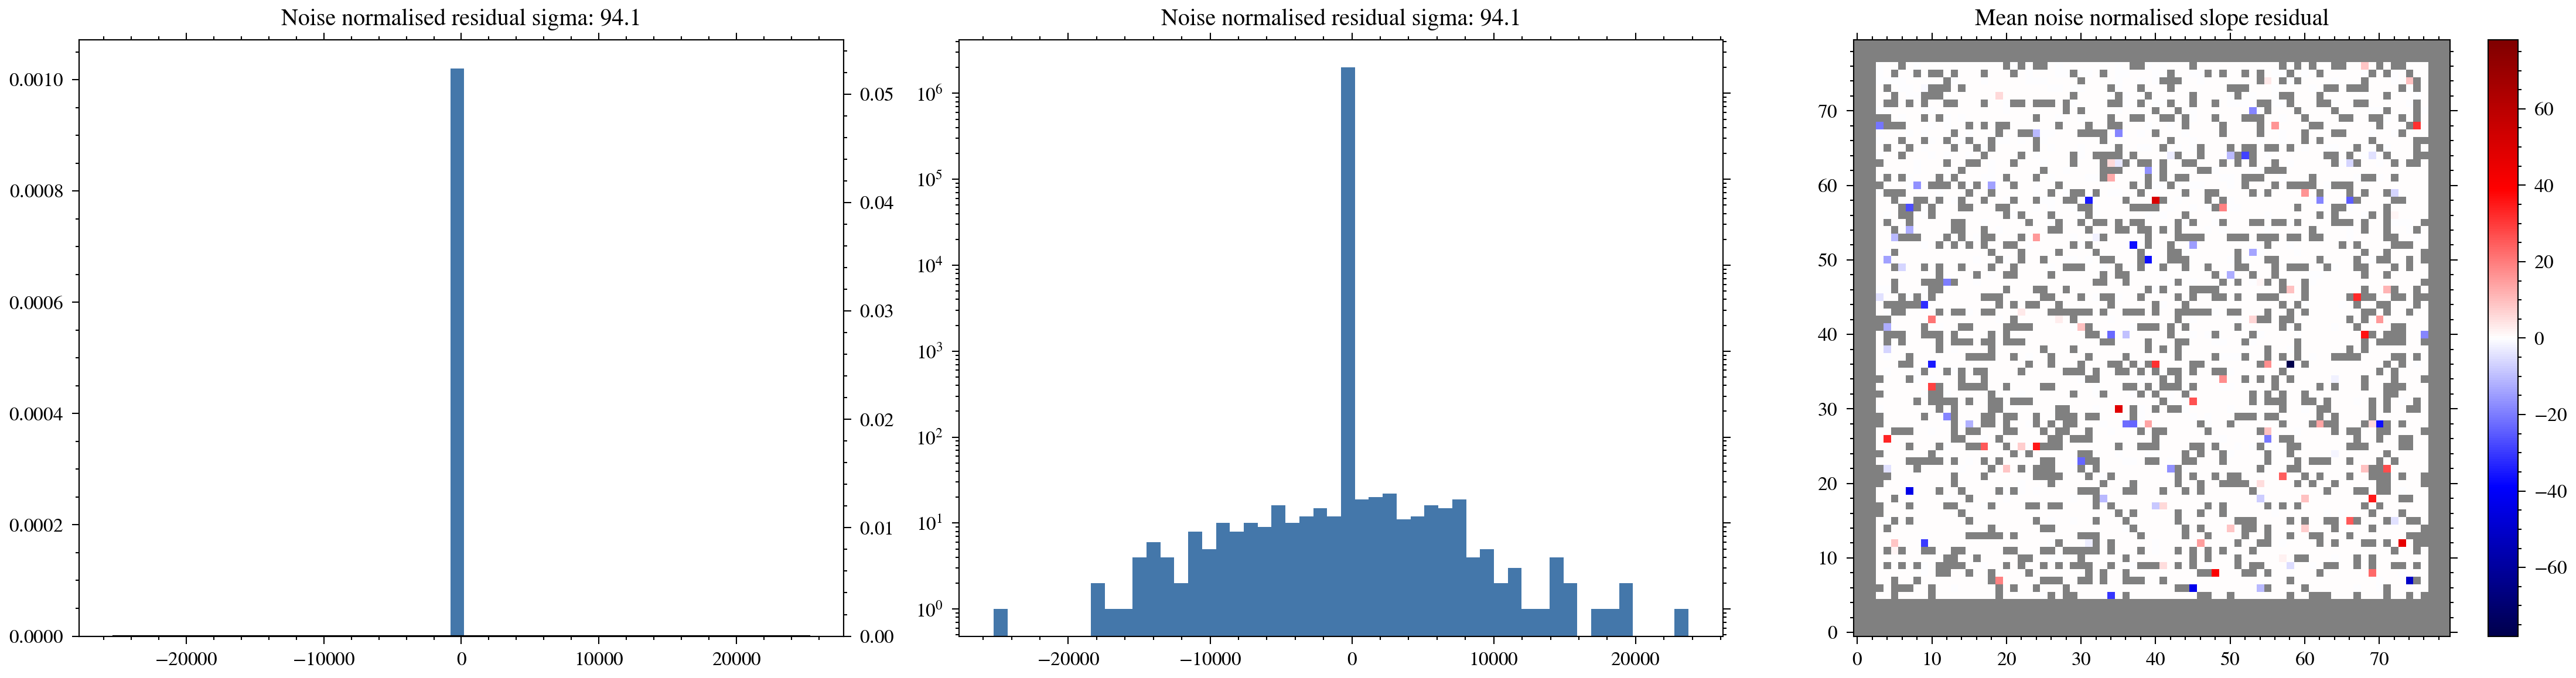

DARK F430M NIS_DARK 50 3752


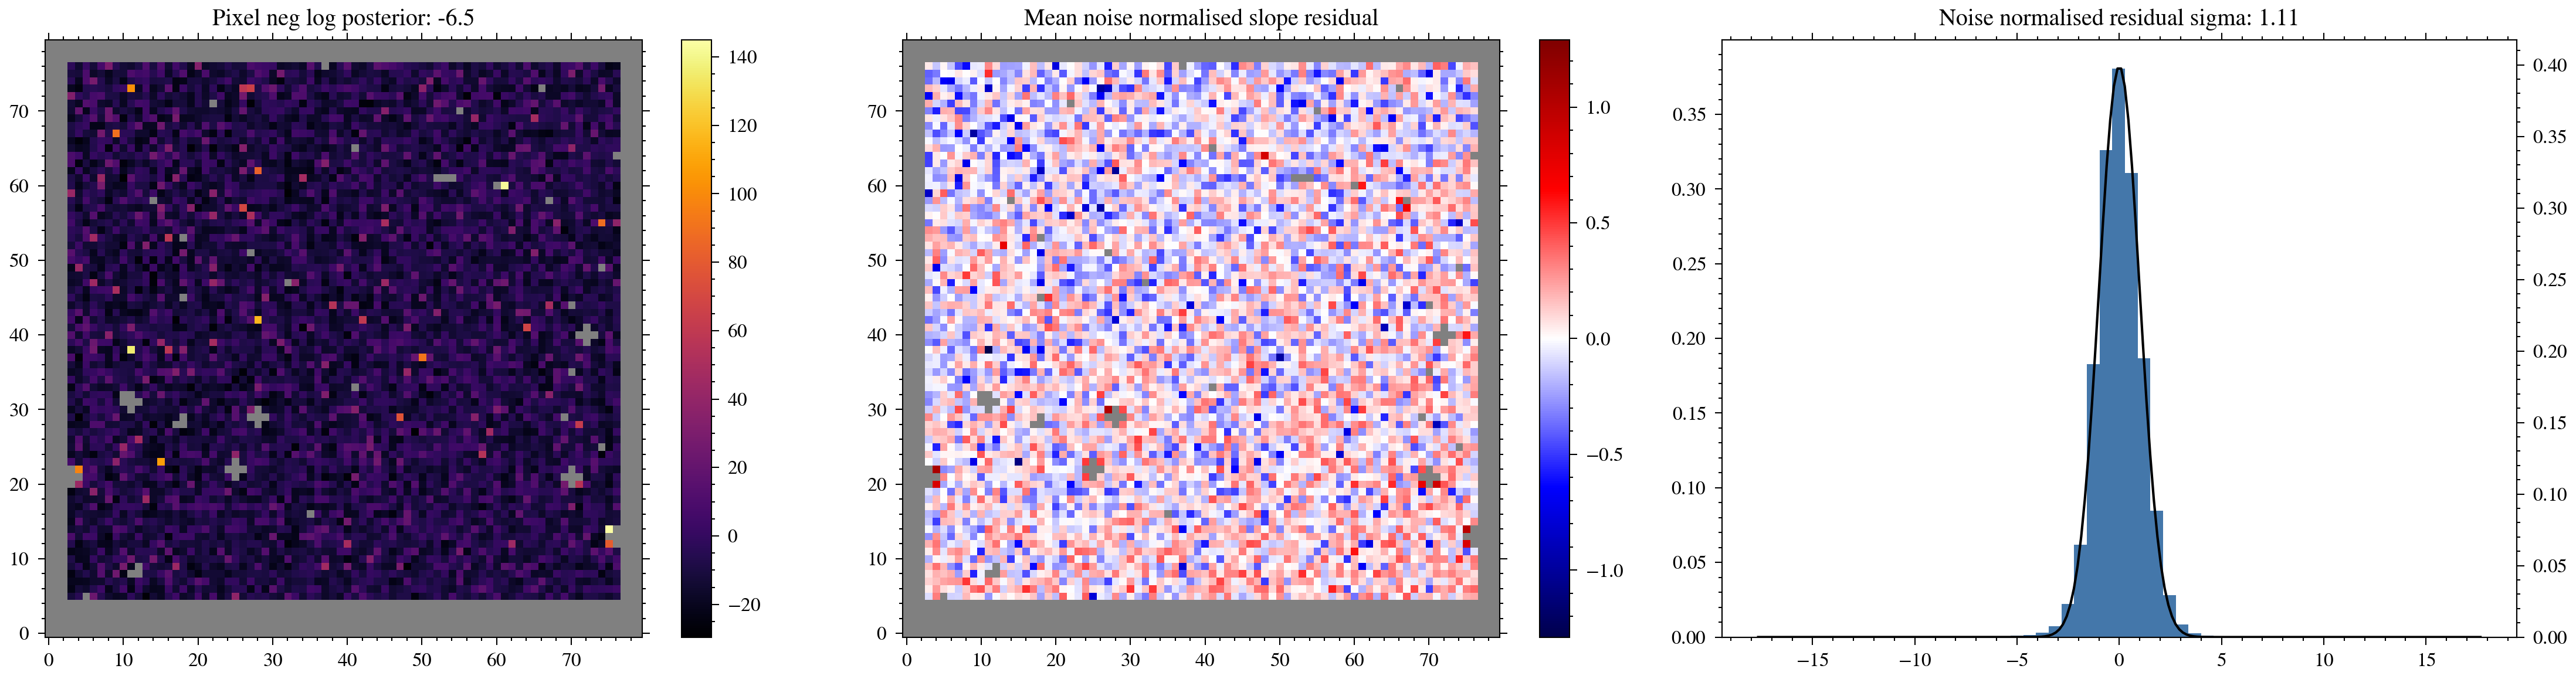

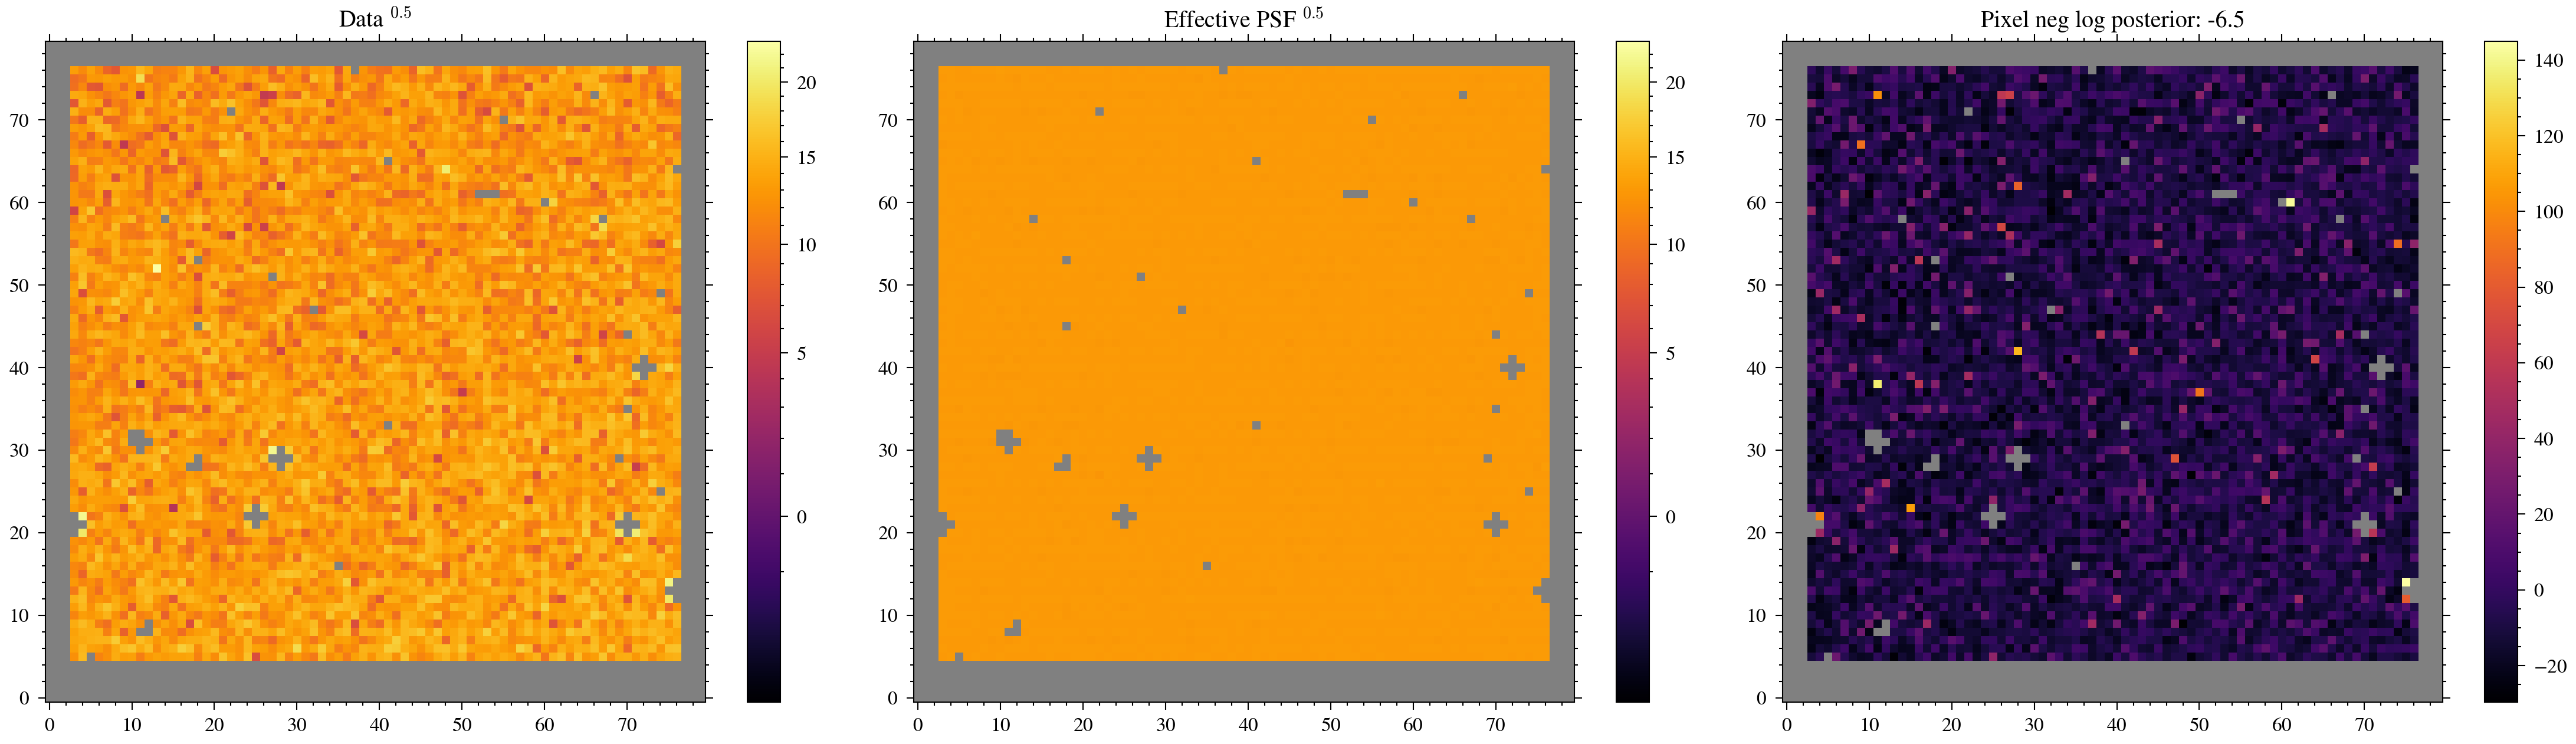

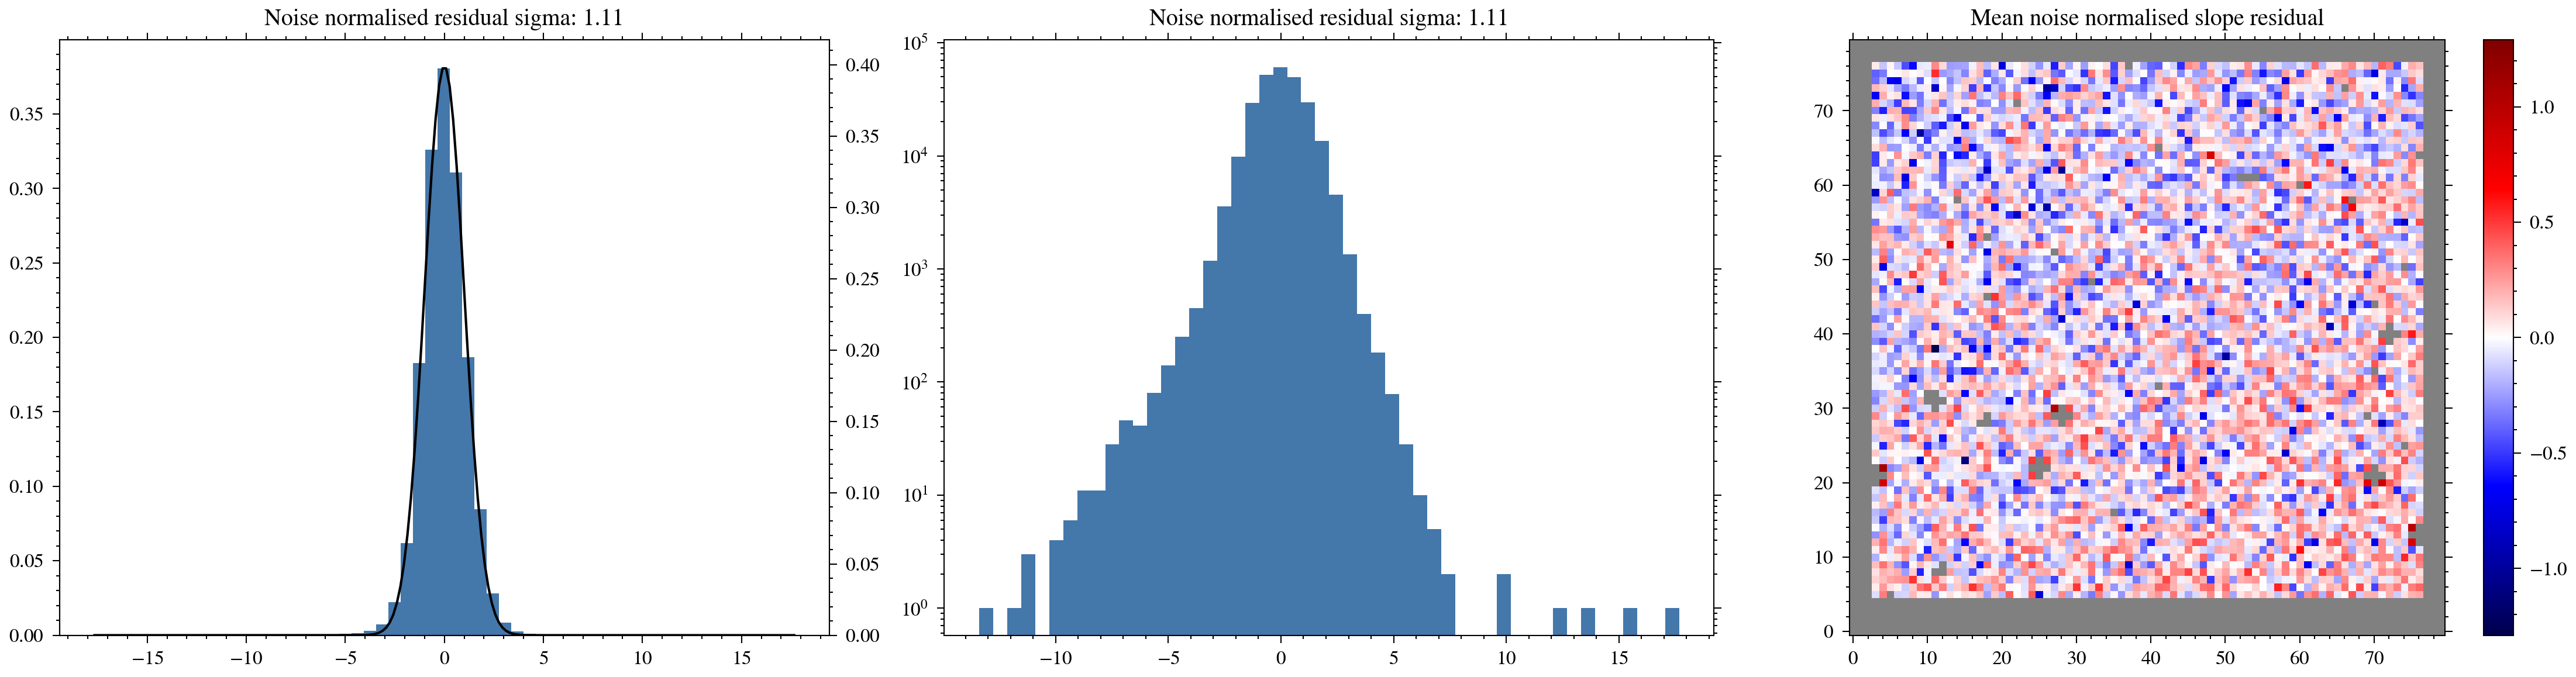

In [9]:
from amigo.plotting import summarise_fit

if plot_flag:
    for exp in dark_exposures:
        print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints)
        summarise_fit(model, exp, histograms=True, residuals=True)
        # summarise_fit(model, exp, save_path=save_path)

# Optimisation

## Setup
For the neural network training we want to use a custom learning rate warmup and a temperature decay, so we will have to modify a lot of the statistical functions of amigo to be able to handle this

In [10]:
from retrain_fns import (
    loss_fn,
    args_fn,
    looper_fn,
    grads_fn,
    aux_fn,
    ff_reg,
    nl_reg,
    temp_decay,
    cosine_warmup,
)

def norm_fn(model_params, args):
    """
    Normalisation function.
    """
    # if hasattr(model_params, "FF"):
    #     FF = model_params.FF
    #     FF -= np.median(FF) - 1.0
    #     FF = FF.at[badpix].set(1.0)
    #     model_params = model_params.set("FF", FF)

    if hasattr(model_params, "non_linearity"):
        non_lin = model_params.non_linearity.at[:, badpix].set(0)
        model_params = model_params.set("non_linearity", non_lin)

    return model_params, args

# def grads_fn(model, grads, args):
#     print(grads.dark_current)
#     return grads, args


# REGULARISATION
reg_dict = {
    "FF": (1., ff_reg),
    "NL": (1., nl_reg),
}

In [11]:
epochs = 100

Instantiating trainer class and updating fishers.

In [12]:
# from amigo.calibration import ValBatchedTrainer  #, looper_fn, Trainer, aux_fn
from amigo.calibration import Trainer
from dorito.stats import apply_regularisers    

recalculate_flag = False

# NOTE: This seems to nuke the jitter/SRF gradient??
linear_model = model.set(["psf_upsample", "bleed"], [1, False])

# Trainer class
trainer = Trainer(
# trainer = ValBatchedTrainer(
    loss_fn,
    # grad_fn=grads_fn,
    # norm_fn=norm_fn,
    cache=cache_dir,
)

trainer = trainer.update_fishers(
    linear_model,
    exposures,
    parameters=[
        # "dark_current",
        "dark_A",
    ],
    recalculate=recalculate_flag,
)


  0%|          | 0/2 [00:00<?, ?it/s]

Training.

In [13]:
from amigo.fitting import sgd, adam

# Define the optimisers
optimisers = {
    # "dark_current": sgd(1e-100, 1000),
    "dark_A": sgd(1e-1, 0),
    # "non_linearity": sgd(1e-400, 100),
    # "non_linearity": sgd(1e-4, 10),
}


# This seems to fix some recompile issues
def fn(x):
    if isinstance(x, jax.Array):
        if "i" in x.dtype.str:
            return x
        return np.array(x, dtype=float)
    return x
model = jtu.map(fn, model)

# Train the model
result = trainer.train(
    model=model,
    optimisers=optimisers,
    epochs=epochs,
    batches=exposures,
)

  0%|          | 0/100 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 1,105,370.48
Loss is NaN on epoch 1, exiting fit
Full Time: 0:00:09
Final Loss: nan


Plotting the results of that fit!

In [ ]:
# amigo.plotting.plot_losses(result.losses[0], start=int(epochs * 0.75))
amigo.plotting.plot(result.history)
if save_flag:
    amigo.plotting.plot(result.history, save_path=save_path)

for exp in exposures:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp, save_path=None)
    
    # if save_flag:
    #     amigo.plotting.summarise_fit(result.model, exp, save_path=this_save_path)